In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.gridspec as gridspec
import numpy as np
import glob

## DATA LOADING & CLEANING

In [ ]:
def load_logs(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.json_normalize(data)

spear_df = load_logs('logs/telemetry_SPEAR_mistral-small3.2_llama3.2.json')
spear_hyde_df = load_logs('logs/telemetry_SPEAR_HYDE_phi3.5:3.8b.json')

df = pd.concat([spear_df, spear_hyde_df], ignore_index=True)


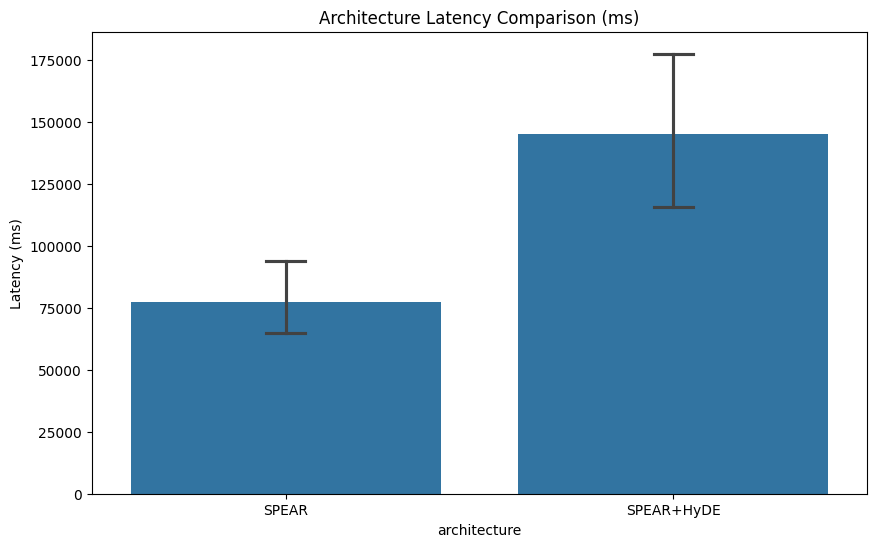

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='latency_ms', data=df, capsize=.1)
plt.title('Architecture Latency Comparison (ms)')
plt.ylabel('Latency (ms)')
plt.show()


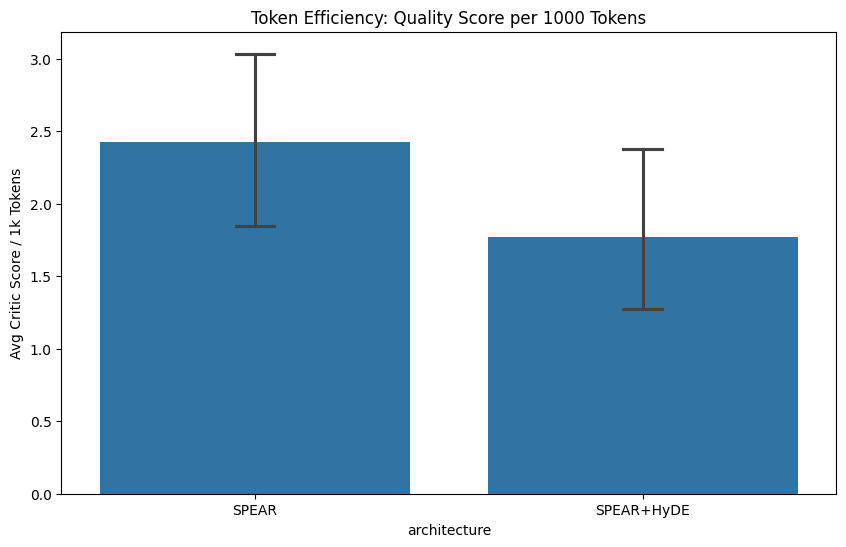

In [ ]:
critic_cols = [
    'async_critic_scores.rule_accuracy', 
    'async_critic_scores.narrative_coherence', 
    'async_critic_scores.npc_voice_consistency'
]
df['avg_critic_score'] = df[critic_cols].mean(axis=1)
df['total_critic_score'] = df[critic_cols].sum(axis=1)
df['score_per_1k_tokens'] = (df['avg_critic_score'] / df['total_tokens']) * 1000

plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='score_per_1k_tokens', data=df, capsize=.1)
plt.title('Token Efficiency: Quality Score per 1000 Tokens')
plt.ylabel('Avg Critic Score / 1k Tokens')
plt.show()

/tmp/ipykernel_3522/72135916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='architecture', y=col, data=df, palette=arch_colors, ax=ax)
/tmp/ipykernel_3522/72135916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='architecture', y=col, data=df, palette=arch_colors, ax=ax)
/tmp/ipykernel_3522/72135916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='architecture', y=col, data=df, palette=arch_colors, ax=ax)


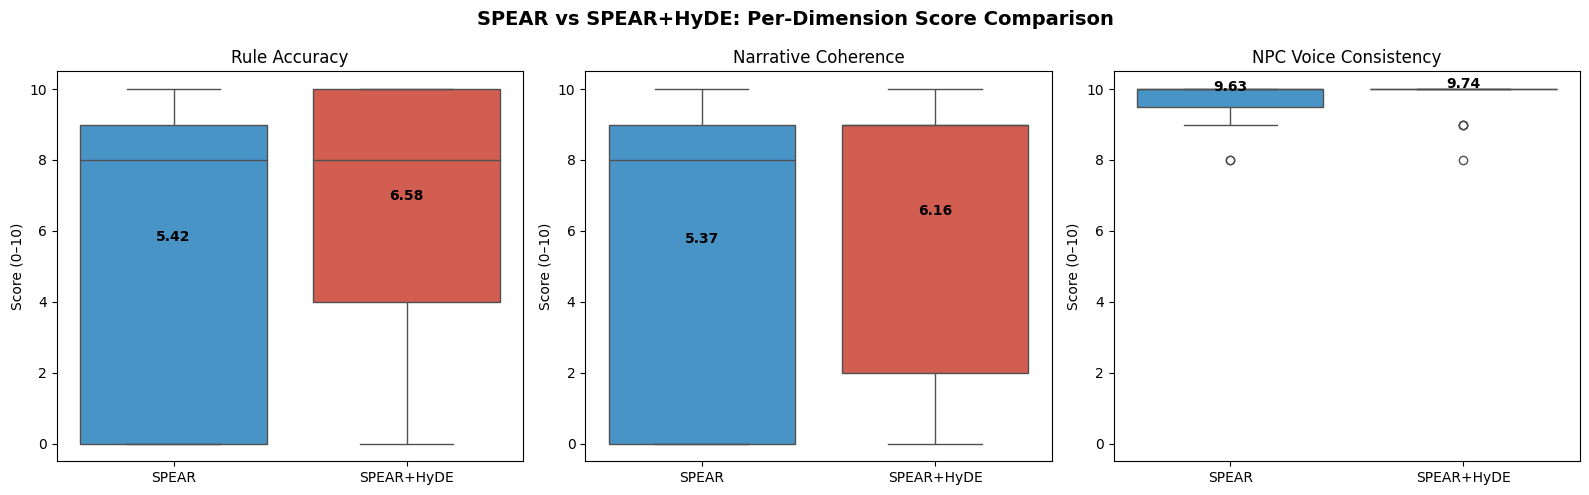

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SPEAR vs SPEAR+HyDE: Per-Dimension Score Comparison', fontsize=14, fontweight='bold')

dims = {
    'Rule Accuracy': 'async_critic_scores.rule_accuracy',
    'Narrative Coherence': 'async_critic_scores.narrative_coherence',
    'NPC Voice Consistency': 'async_critic_scores.npc_voice_consistency'
}
arch_colors = {'SPEAR': '#3498db', 'SPEAR+HyDE': '#e74c3c'}

for ax, (label, col) in zip(axes, dims.items()):
    sns.boxplot(x='architecture', y=col, data=df, palette=arch_colors, ax=ax)
    ax.set_title(label)
    ax.set_ylabel('Score (0–10)')
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlabel('')
    # Annotate means
    for i, arch in enumerate(df['architecture'].unique()):
        mean = df[df['architecture'] == arch][col].mean()
        ax.text(i, mean + 0.3, f'{mean:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

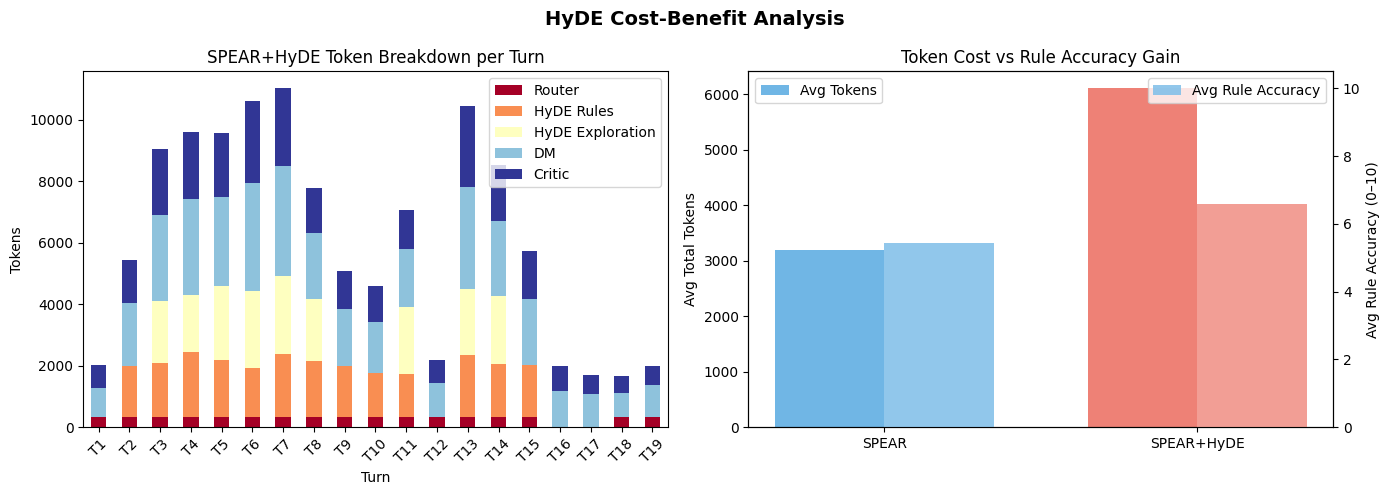

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HyDE Cost-Benefit Analysis', fontsize=14, fontweight='bold')

# Left: token breakdown showing where HyDE tokens go
spear_hyde_only = df[df['architecture'] == 'SPEAR+HyDE'].copy().reset_index(drop=True)

token_components = pd.DataFrame({
    'Router':          spear_hyde_only['token_breakdown.router'].fillna(0),
    'HyDE Rules':      spear_hyde_only['token_breakdown.hyde_rules'].fillna(0),
    'HyDE Exploration':spear_hyde_only['token_breakdown.hyde_exploration'].fillna(0),
    'DM':              spear_hyde_only['token_breakdown.dm'].fillna(0),
    'Critic':          spear_hyde_only['token_breakdown.critic'].fillna(0),
})
token_components.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlBu')
axes[0].set_title('SPEAR+HyDE Token Breakdown per Turn')
axes[0].set_xlabel('Turn')
axes[0].set_ylabel('Tokens')
axes[0].set_xticklabels([f"T{i+1}" for i in range(len(token_components))], rotation=45)

# Right: total tokens side by side with mean rule_accuracy
ax2 = axes[1]
means = df.groupby('architecture').agg(
    avg_tokens=('total_tokens', 'mean'),
    avg_rule_accuracy=('async_critic_scores.rule_accuracy', 'mean')
).reset_index()

x = np.arange(len(means))
width = 0.35
bars1 = ax2.bar(x - width/2, means['avg_tokens'], width, label='Avg Tokens', color=['#3498db', '#e74c3c'], alpha=0.7)
ax2b = ax2.twinx()
bars2 = ax2b.bar(x + width/2, means['avg_rule_accuracy'], width, label='Avg Rule Accuracy', color=['#85C1E9', '#F1948A'], alpha=0.9)
ax2.set_xticks(x)
ax2.set_xticklabels(means['architecture'])
ax2.set_ylabel('Avg Total Tokens', color='black')
ax2b.set_ylabel('Avg Rule Accuracy (0–10)', color='black')
ax2b.set_ylim(0, 10.5)
ax2.set_title('Token Cost vs Rule Accuracy Gain')
ax2.legend(loc='upper left')
ax2b.legend(loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3522/1120994081.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='architecture', y='parallel_fetch_ms', data=phase2_data,


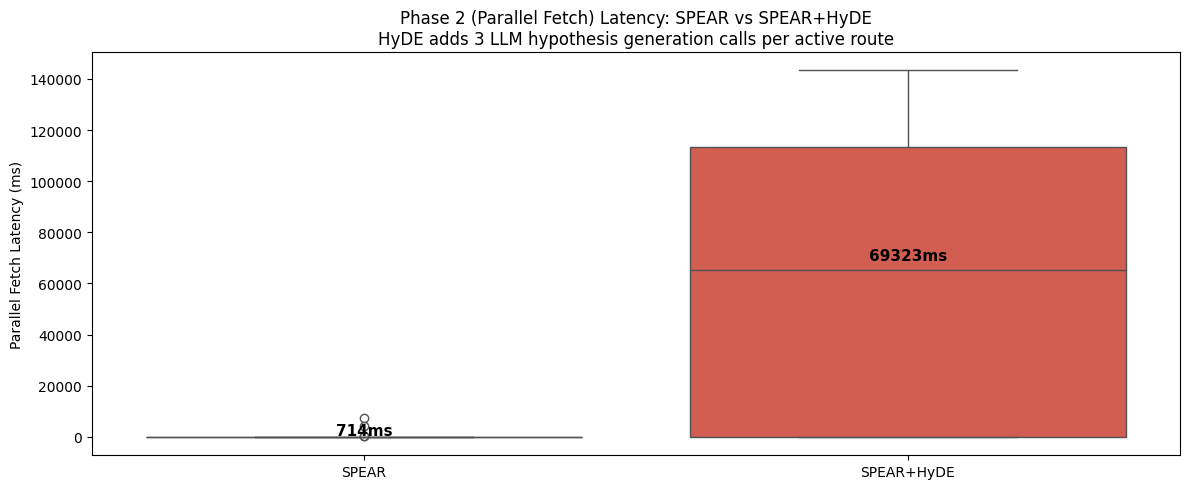

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

phase2_data = df[['architecture', 'latency_breakdown.parallel_fetch_ms']].dropna()
phase2_data = phase2_data.rename(columns={'latency_breakdown.parallel_fetch_ms': 'parallel_fetch_ms'})

sns.boxplot(x='architecture', y='parallel_fetch_ms', data=phase2_data,
            palette={'SPEAR': '#3498db', 'SPEAR+HyDE': '#e74c3c'}, ax=ax)

for i, arch in enumerate(phase2_data['architecture'].unique()):
    mean = phase2_data[phase2_data['architecture'] == arch]['parallel_fetch_ms'].mean()
    ax.text(i, mean + 20, f'{mean:.0f}ms', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Phase 2 (Parallel Fetch) Latency: SPEAR vs SPEAR+HyDE\n'
             'HyDE adds 3 LLM hypothesis generation calls per active route')
ax.set_ylabel('Parallel Fetch Latency (ms)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3522/2768546695.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='async_critic_scores.rule_accuracy',


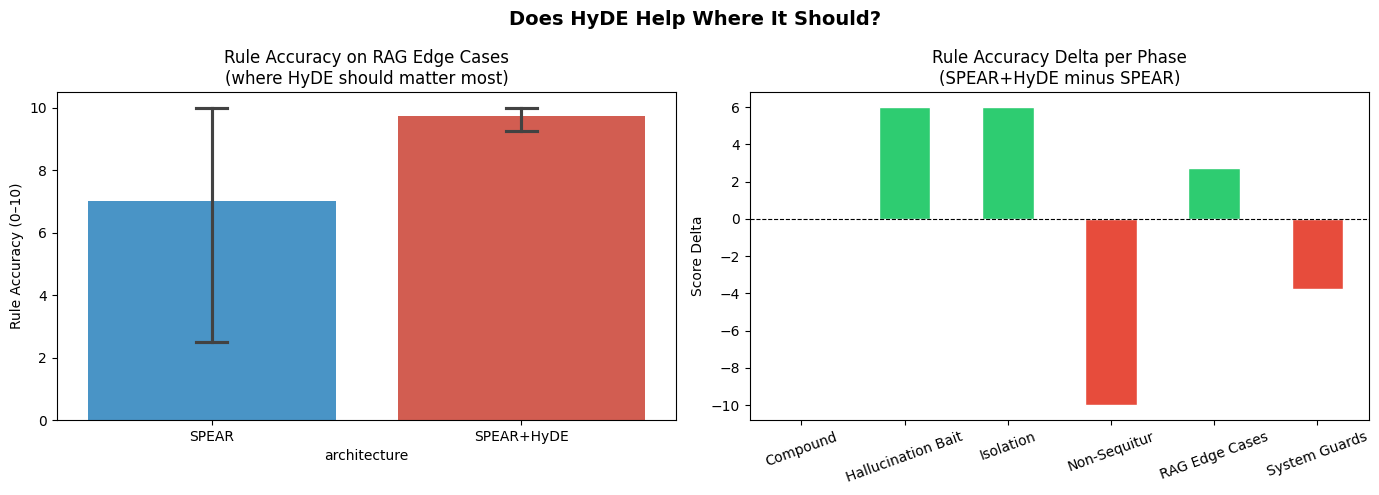

In [ ]:
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur'
]
df['phase'] = df.groupby('architecture').cumcount().map(dict(enumerate(phase_labels)))

rag_only = df[df['phase'] == 'RAG Edge Cases']
all_phases = df.groupby(['architecture', 'phase'])['async_critic_scores.rule_accuracy'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Does HyDE Help Where It Should?', fontsize=14, fontweight='bold')

# Left: rule accuracy on RAG edge cases only
sns.barplot(x='architecture', y='async_critic_scores.rule_accuracy',
            data=rag_only, palette={'SPEAR': '#3498db', 'SPEAR+HyDE': '#e74c3c'},
            capsize=0.1, ax=axes[0])
axes[0].set_title('Rule Accuracy on RAG Edge Cases\n(where HyDE should matter most)')
axes[0].set_ylabel('Rule Accuracy (0–10)')
axes[0].set_ylim(0, 10.5)

# Right: rule accuracy delta across all phases
pivot = all_phases.pivot(index='phase', columns='architecture', values='async_critic_scores.rule_accuracy')
pivot['delta'] = pivot.get('SPEAR+HyDE', 0) - pivot.get('SPEAR', 0)
pivot['delta'].plot(kind='bar', ax=axes[1],
                    color=['#2ecc71' if v >= 0 else '#e74c3c' for v in pivot['delta']],
                    edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Rule Accuracy Delta per Phase\n(SPEAR+HyDE minus SPEAR)')
axes[1].set_ylabel('Score Delta')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

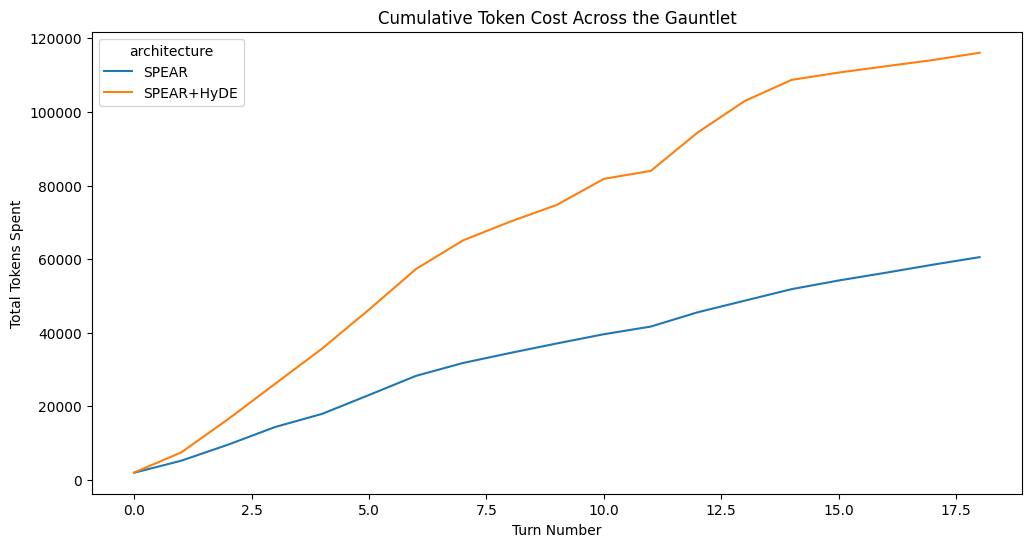

In [ ]:
df_sorted = df.sort_values('timestamp_utc')
df_sorted['cumulative_tokens'] = df_sorted.groupby('architecture')['total_tokens'].cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=df_sorted.groupby('architecture').cumcount(), 
             y='cumulative_tokens', 
             hue='architecture', 
             data=df_sorted)
plt.title('Cumulative Token Cost Across the Gauntlet')
plt.xlabel('Turn Number')
plt.ylabel('Total Tokens Spent')
plt.show()

/tmp/ipykernel_3522/1143729308.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='avg_critic_score', data=df,
/tmp/ipykernel_3522/1143729308.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='score_per_1k', data=df,


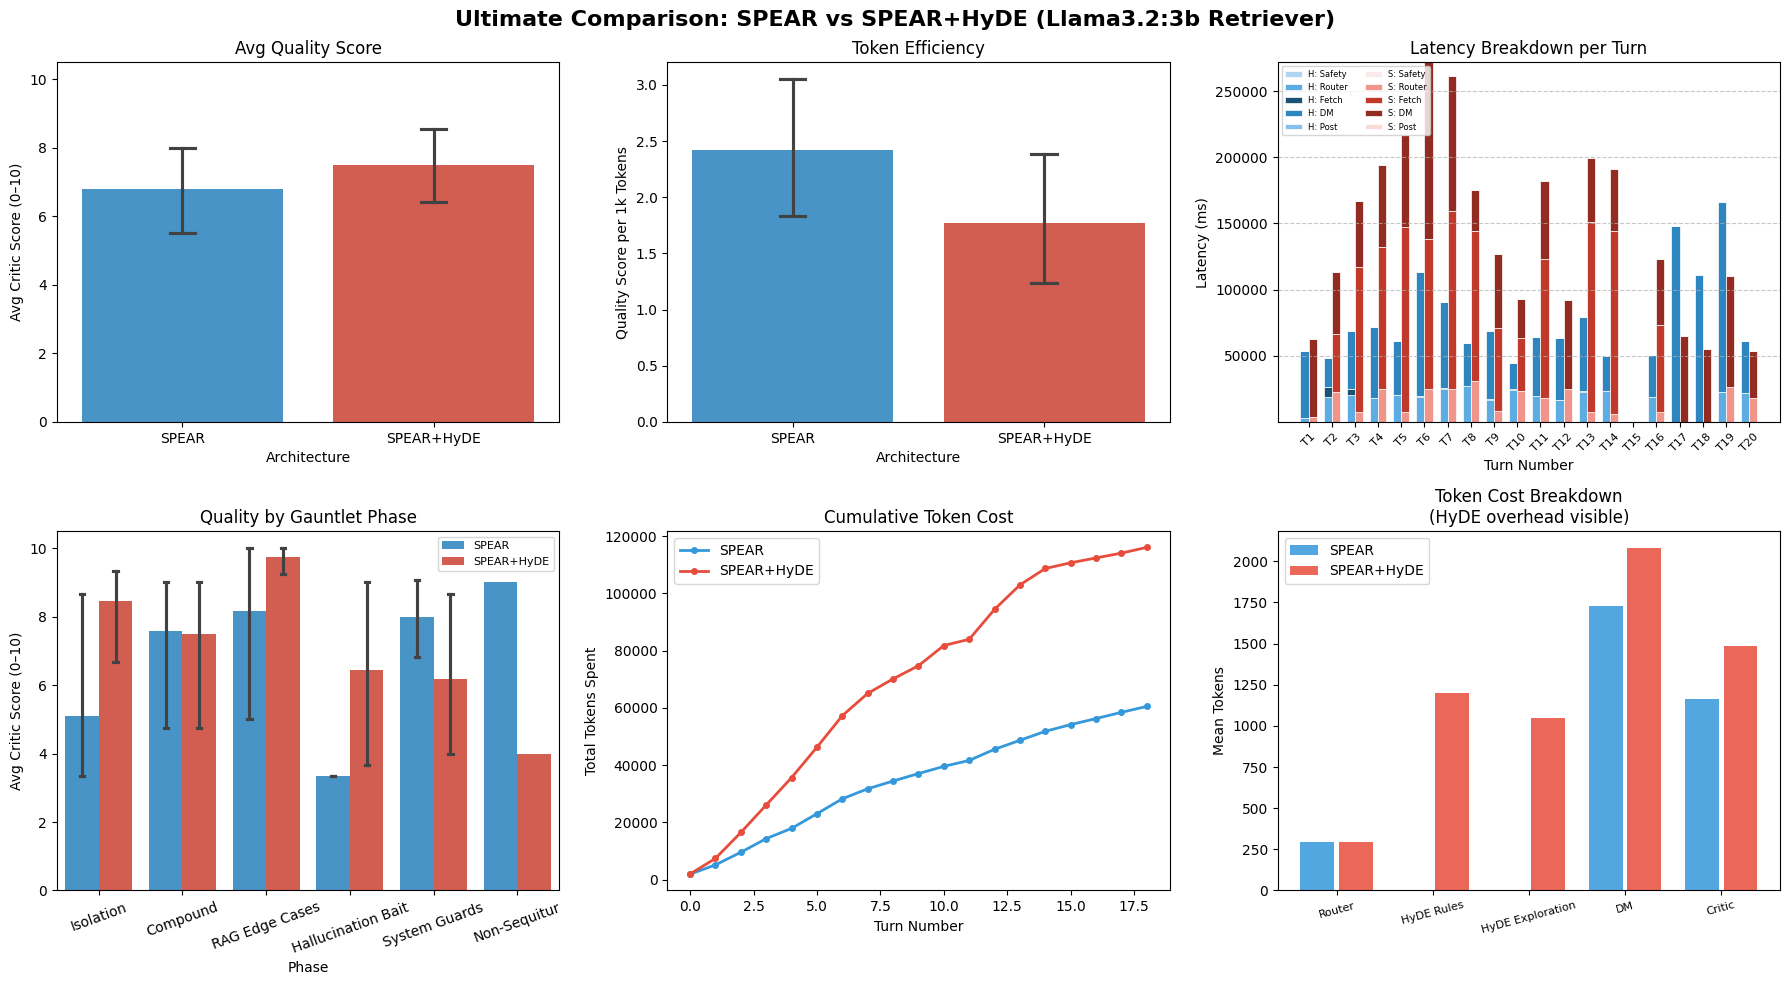

In [ ]:
critic_cols = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]

df['avg_critic_score'] = df[critic_cols].mean(axis=1)
df['score_per_1k'] = (df['avg_critic_score'] / df['total_tokens']) * 1000

arch_colors = {'SPEAR': '#3498db', 'SPEAR+HyDE': '#e74c3c'}
spear_label = df[df['architecture'] == 'SPEAR+HyDE']['architecture'].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Ultimate Comparison: SPEAR vs SPEAR+HyDE (Llama3.2:3b Retriever)", fontsize=16, fontweight='bold')

# ==========================================
# 1. Avg Quality Score
# ==========================================
ax = axes[0, 0]
sns.barplot(x='architecture', y='avg_critic_score', data=df,
            palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Avg Quality Score')
ax.set_xlabel('Architecture')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)

# ==========================================
# 2. Token Efficiency
# ==========================================
ax = axes[0, 1]
sns.barplot(x='architecture', y='score_per_1k', data=df,
            palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Token Efficiency')
ax.set_xlabel('Architecture')
ax.set_ylabel('Quality Score per 1k Tokens')

# ==========================================
# 3. Latency Breakdown per Turn (Side-by-Side Stacked)
# ==========================================
ax = axes[0, 2]

spear_hyde_df = df[df['architecture'] == 'SPEAR'].reset_index(drop=True)
spear_df = df[df['architecture'] == 'SPEAR+HyDE'].reset_index(drop=True)

spear_components = pd.DataFrame({
    'S: Safety':  spear_df['latency_breakdown.safety_filter_ms'].fillna(0),
    'S: Router':  spear_df['latency_breakdown.router_ms'].fillna(0),
    'S: Fetch':   spear_df['latency_breakdown.parallel_fetch_ms'].fillna(0),
    'S: DM':      spear_df['latency_breakdown.dm_ms'].fillna(0),
    'S: Post':    spear_df['latency_breakdown.post_processing_ms'].fillna(0),
})

# Both SPEAR and SPEAR+HyDE have identical column names — the only 
# difference is parallel_fetch_ms will be visibly higher for HyDE
hyde_components = pd.DataFrame({
    'H: Safety':  spear_hyde_df['latency_breakdown.safety_filter_ms'].fillna(0),
    'H: Router':  spear_hyde_df['latency_breakdown.router_ms'].fillna(0),
    'H: Fetch':   spear_hyde_df['latency_breakdown.parallel_fetch_ms'].fillna(0),
    'H: DM':      spear_hyde_df['latency_breakdown.dm_ms'].fillna(0),
    'H: Post':    spear_hyde_df['latency_breakdown.post_processing_ms'].fillna(0),
})

# Handle SPEAR's missing Turn 15 (if length is 19)
if len(spear_components) == 19:
    zero_row = pd.DataFrame(0, index=[14], columns=spear_components.columns)
    spear_components = pd.concat([
        spear_components.iloc[:14],
        zero_row,
        spear_components.iloc[14:]
    ]).reset_index(drop=True)

if len(hyde_components) == 19:
    zero_row = pd.DataFrame(0, index=[14], columns=hyde_components.columns)
    hyde_components = pd.concat([
        hyde_components.iloc[:14],
        zero_row,
        hyde_components.iloc[14:]
    ]).reset_index(drop=True)

baseline_colors = ['#AED6F1', '#5DADE2', '#1A5276', '#2E86C1', '#85C1E9', '#D6EAF8']
spear_colors = ['#F9EBEA', '#F1948A', '#C0392B', '#922B21', '#FADBD8']

x = np.arange(len(hyde_components))
width = 0.35  

# Plot Baseline
bottom_base = np.zeros(len(hyde_components))
for idx, col in enumerate(hyde_components.columns):
    ax.bar(x - width/2, hyde_components[col], width, label=col,
           bottom=bottom_base, color=baseline_colors[idx], edgecolor='white', linewidth=0.5)
    bottom_base += hyde_components[col].values

# Plot SPEAR
bottom_spear = np.zeros(len(spear_components))
for idx, col in enumerate(spear_components.columns):
    ax.bar(x + width/2, spear_components[col], width, label=col,
           bottom=bottom_spear, color=spear_colors[idx], edgecolor='white', linewidth=0.5)
    bottom_spear += spear_components[col].values

ax.set_title('Latency Breakdown per Turn')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(len(hyde_components))], rotation=45, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Compress legend to fit nicely in the subplot
ax.legend(loc='upper left', fontsize=6, ncol=2)


# ==========================================
# 4. Quality by Gauntlet Phase
# ==========================================
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur'
]
df['phase'] = df.groupby('architecture').cumcount().map(dict(enumerate(phase_labels)))
ax = axes[1, 0]
sns.barplot(x='phase', y='avg_critic_score', hue='architecture',
            data=df, palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Quality by Gauntlet Phase')
ax.set_xlabel('Phase')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=8)

# ==========================================
# 5. Cumulative Token Cost
# ==========================================
ax = axes[1, 1]
df_sorted = df.sort_values('timestamp_utc')
df_sorted['cumulative_tokens'] = df_sorted.groupby('architecture')['total_tokens'].cumsum()
for arch, color in arch_colors.items():
    subset = df_sorted[df_sorted['architecture'] == arch].reset_index(drop=True)
    ax.plot(range(len(subset)), subset['cumulative_tokens'],
            color=color, linewidth=2, label=arch, marker='o', markersize=4)
ax.set_title('Cumulative Token Cost')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Total Tokens Spent')
ax.legend()

# ==========================================
# 6. Quality Score Dimensions Side by Side
# ==========================================
# axes[1, 2] — replace with token cost breakdown
ax = axes[1, 2]
token_cols = {
    'Router':           'token_breakdown.router',
    'HyDE Rules':       'token_breakdown.hyde_rules',
    'HyDE Exploration': 'token_breakdown.hyde_exploration',
    'DM':               'token_breakdown.dm',
    'Critic':           'token_breakdown.critic',
}
for arch, color, offset in [('SPEAR', '#3498db', -0.2), ('SPEAR+HyDE', '#e74c3c', 0.2)]:
    subset = df[df['architecture'] == arch]
    means = [subset[col].fillna(0).mean() for col in token_cols.values()]
    # For SPEAR, hyde_rules and hyde_exploration will be 0 — that's the point
    ax.bar(
        np.arange(len(token_cols)) + offset,
        means, 0.35, label=arch,
        color=color, alpha=0.85
    )
ax.set_xticks(np.arange(len(token_cols)))
ax.set_xticklabels(list(token_cols.keys()), fontsize=8, rotation=15)
ax.set_title('Token Cost Breakdown\n(HyDE overhead visible)')
ax.set_ylabel('Mean Tokens')
ax.legend()

plt.tight_layout()
plot_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'plot')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'spear_hyde_phi3.5:3.8b.png'), dpi=150, bbox_inches='tight')
plt.show()